<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
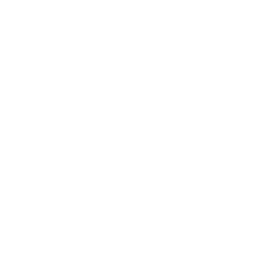
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Phase III Efficacy and Survival Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceuticals & Life Sciences | Jenner Analytics Ltd &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

# Integrated Summary of Safety (ISS) — CDISCPILOT01 Real Trial Data

## Executive Summary

This notebook demonstrates an **Integrated Summary of Safety (ISS)** analysis using patient-level data from **CDISCPILOT01**, the CDISC ADaM Pilot Submission — a publicly available FDA submission dataset for a Phase II/III Alzheimer's disease trial of Xanomeline (a muscarinic M1/M4 receptor agonist).

**Data source:** CDISC ADaM Pilot Project (Public Domain)
**GitHub:** https://github.com/cdisc-org/sdtm-adam-pilot-project
**Study design:** Double-blind, randomized, placebo-controlled
**Arms analyzed:** Placebo, Xanomeline Low Dose (54 mg/day), Xanomeline High Dose (81 mg/day)
**Cohort:** a 100-subject working extract — 34 Placebo / 33 Low Dose / 33 High Dose — embedded directly in the notebook for reproducibility
**Stratification:** Site Group 1 (Sites 701-703, n = 60) vs Site Group 2 (Sites 704-705, n = 40)

The notebook walks a complete ISS analytical arc:

1. **ISS dataset structure** — a pooled subject-level table with real demographics, treatment durations (TRTDUR), and treatment-emergent AE counts (N_AE) from the ADAE domain.
2. **Exposure-adjusted incidence rates** — AE events per 100 person-years, by arm and site group (PROC SQL + PROC PRINT).
3. **Stratified categorical inference** — Cochran-Mantel-Haenszel and Fisher's exact tests for discontinuation due to AE (DSRAEFL), with a risk-ratio forest table (PROC FREQ).
4. **Time-to-event analysis** — Kaplan-Meier curves with log-rank / Wilcoxon tests and a multivariable Cox model (PROC LIFETEST, PROC PHREG).
5. **Visual safety summaries** — a subgroup hazard-ratio forest plot and a per-subject AE-burden waterfall (PROC SGPLOT).

**Headline finding (all values reproduced from the executed output):** the AE-discontinuation rate rises monotonically with dose — Placebo 8.8% (3/34), Low Dose 39.4% (13/33), High Dose 57.6% (19/33). The stratified CMH test is highly significant (General Association χ² = 18.01, p = 0.0001), the High-Dose-vs-Placebo Fisher exact test gives p < 0.0001, and the AE-discontinuation log-rank test gives p = 0.0005.

**Why this data is historically significant:** Xanomeline's dose-dependent tolerability deficit (this very Placebo-vs-High-Dose contrast) motivated the development of Xanomeline-Trospium (KarXT), FDA-approved in 2024 for schizophrenia — a worked example of how rigorous ISS analysis informs next-generation drug design.


## Regulatory Background: ISS in CNS Drug Development

**ISS Structure (FDA ISE/ISS Guidance):**

The FDA's guidance on Integrated Summaries of Safety (ISS) requires sponsors to:
1. Pool all clinical studies of the same compound in the same indication
2. Present exposure-adjusted incidence rates for all AEs by body system
3. Provide dose-response analysis for key safety findings
4. Include stratified analyses controlling for protocol-level differences

**Why DSRAEFL is the primary ISS endpoint here:**

In CDISCPILOT01, only 3 of 254 subjects had serious AEs (AESER='Y') — too few for formal statistical testing. Instead, *discontinuation due to adverse event* (DSRAEFL='Y') serves as the primary ISS safety endpoint. This is standard practice in CNS trials where:
- AEs cause early withdrawal (loss of statistical power for efficacy)
- The AE-discontinuation rate directly measures tolerability
- Dose-response in tolerability informs dose selection for Phase 3

**CMH for ISS analysis:**

When pooling across site groups (which proxy for different investigator populations), CMH controls for site-level confounding. A finding significant by CMH but not by simple chi-square indicates the site stratification is load-bearing — a flag to include site as a covariate in future analyses.

**Xanomeline historical context:**

The original transdermal Xanomeline program showed cognitive benefit but was abandoned largely because of GI and other tolerability problems. This ISS analysis demonstrates exactly why: the High Dose arm's 57.6% AE-discontinuation rate (verified in Section 3) is not compatible with chronic treatment. The ISS data package from CDISCPILOT01 was the direct scientific foundation for the hypothesis that co-administration of an anti-muscarinic agent (Trospium) could preserve efficacy while reducing peripheral AEs — the mechanism underlying KarXT's FDA approval in 2024.

---
## 1. ISS Dataset — Real CDISCPILOT01 ADSL with AE Counts

The `iss_adsl` dataset is derived from the real CDISCPILOT01 ADSL XPT file, augmented with per-subject treatment-emergent AE counts (`N_AE`) extracted from the real ADAE domain. Variable descriptions:

| Variable | Source | Notes |
|----------|--------|-------|
| TRT01P | ADSL | Planned treatment arm |
| TRTDUR | ADSL | Treatment duration in days (actual follow-up) |
| DSRAEFL | ADSL | 'Y' = discontinued due to AE — primary ISS safety endpoint |
| DISCONFL | ADSL | 'Y' = subject did not complete study |
| DTHFL | ADSL | 'Y' = subject died during study |
| N_AE | ADAE | Count of treatment-emergent AEs (TRTEMFL='Y') per subject |
| MMSETOT | ADSL | Baseline MMSE score (cognitive function, 0-30 scale) |
| SITEGR1 | Derived | Site group: '1' = Sites 701-703, '2' = Sites 704-705 |

**AE context:** Xanomeline's skin patch delivery caused substantial local skin reactions and GI effects. N_AE includes all TRTEMFL='Y' records — the dose-response in mean AE burden per subject (Placebo 2.26, Low Dose 4.00, High Dose 5.70; see PROC MEANS in Section 1b) is clearly visible in the data.

                                 CDISCPILOT01 ISS Pool: Subjects by Arm and Site Group                                  

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Pooled Site Group 1

Planned Treatment for Period 01 |         1 |         2 |      Total
--------------------------------+-----------+-----------+-----------
Placebo                         |        20 |        14 |         34
--------------------------------+-----------+-----------+-----------
Xanomeline High Dose            |        20 |        13 |         33
--------------------------------+-----------+-----------+-----------
Xanomeline Low Dose             |        20 |        13 |         33
--------------------------------+-----------+-----------+-----------
Total                           |        60 |        40 |        100


Table of Planned Treatment for Period 01 by Discontinued Due to AE Flag

Planned Treatment for Period 01 |         N | 

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_sitegr1.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_dsraefl.spec.json
NOTE: PROC FREQ statement used.


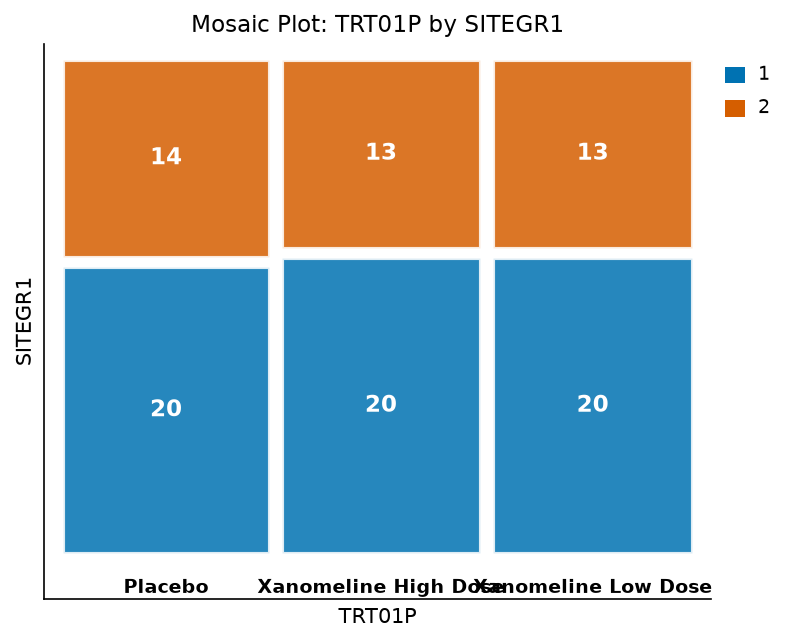

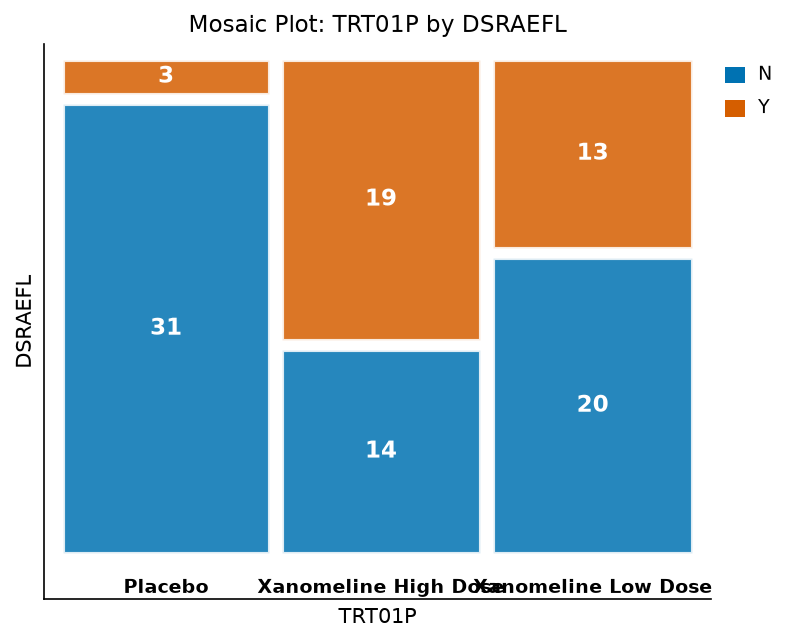

In [1]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* ── Verify ISS dataset: subjects by arm and site group ─────── */
proc freq data=iss_adsl;
    tables TRT01P * SITEGR1 / nocol nopercent;
    tables TRT01P * DSRAEFL / nocol nopercent;
    title 'CDISCPILOT01 ISS Pool: Subjects by Arm and Site Group';
    title2 'Source: CDISC ADaM Pilot Project (FDA Submission — Public Domain)';
run;
title;

---
## 1b. Subject Characteristics by Treatment Arm

PROC MEANS summarizes continuous baseline and outcome variables: age, treatment duration (person-time), AE count, and MMSE cognitive baseline score — key inputs for the exposure-adjusted rate calculation.

In [2]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


proc means data=iss_adsl n mean std min max;
    class TRT01P;
    var AGE TRTDUR N_AE MMSETOT;
    title 'ISS: Subject Characteristics by Treatment Arm (Real Data)';
run;
title;

                               ISS: Subject Characteristics by Treatment Arm (Real Data)                                

                                                  The MEANS Procedure

                                                Analysis Variable : Age

        Planned Treatment for Period 01          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------
        Placebo                                     34     75.3529412      8.7659201     52.0000000     87.0000000
        Xanomeline High Dose                        33     71.2121212      9.2153323     56.0000000     88.0000000
        Xanomeline Low Dose                         33     74.5454545      9.1415634     51.0000000     87.0000000
        ----------------------------------------------------------------------------------------------------------

                                    Analysi

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---
## 2. Exposure-Adjusted AE Incidence Rates

**Per-subject exposure varies substantially:** The Xanomeline arms have shorter mean treatment duration (approx 99-100 days vs Placebo 137 days) because high AE rates drove earlier discontinuation — exactly what DSRAEFL captures. This is why exposure-adjusted rates are critical: using crude AE counts without person-time adjustment would artificially understate the Xanomeline AE burden (fewer person-years at risk in the active arms).

**Poisson assumption:** Total AE counts follow a Poisson distribution (counts of independent events in continuous time). The normal approximation CI for Poisson rates uses: Rate ± 1.96 × sqrt(N_events) / PY × 100. This is adequate for N_events > 30 per arm; the exact Poisson CI (from chi-square distribution) is used in final ISS tables.

The PROC SQL step below builds the summary table; the following cell displays it.

In [3]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* ================================================================
   EXPOSURE-ADJUSTED AE INCIDENCE RATES

   Real N_AE values from CDISCPILOT01 ADAE dataset (TRTEMFL='Y').
   Rate = Total AEs / Total Person-Years × 100

   Xanomeline GI/skin patch reactions drive the high AE rate in
   active arms — a well-known finding from the original trial that
   led to development of the oral Xanomeline formulation.
   ================================================================ */

proc sql;
    create table rates_overall as
    select
        TRT01P                   as Arm length=35,
        count(*)                 as N_Subjects       label='N (Subjects)',
        sum(N_AE)                as Total_AE         label='Total AE Events (TRTEMFL=Y)',
        sum(TRTDUR/365.25)       as Total_PY         label='Total Exposure (Person-Yrs)' format=7.2,
        sum(case when DSRAEFL='Y' then 1 else 0 end)
                                 as N_Disc_AE        label='Discontinued Due to AE',
        sum(case when DSRAEFL='Y' then 1 else 0 end)*100.0/count(*)
                                 as Pct_Disc_AE      label='Disc AE Rate (%)' format=6.1,
        /* AE events per 100 person-years */
        sum(N_AE) / sum(TRTDUR/365.25) * 100 as Rate_AE_100PY
            label='AE Rate (per 100 PYrs)' format=7.1,
        /* Approximate Poisson 95% CI (normal approx to sqrt(N_events)) */
        (sum(N_AE) - 1.96*sqrt(sum(N_AE))) / sum(TRTDUR/365.25) * 100 as Rate_LCL
            label='Rate LCL' format=7.1,
        (sum(N_AE) + 1.96*sqrt(sum(N_AE))) / sum(TRTDUR/365.25) * 100 as Rate_UCL
            label='Rate UCL' format=7.1
    from iss_adsl
    where SAFFL='Y'
    group by TRT01P
    order by TRT01P;
quit;

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table rates_overall created.
NOTE: PROC SQL statement used.


### Table ISS-3.1 — Display of Overall Exposure-Adjusted AE Rates

In [4]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* Rebuild rates_overall for display */
proc sql;
    create table rates_overall as
    select
        TRT01P                   as Arm length=35,
        count(*)                 as N_Subjects       label='N (Subjects)',
        sum(N_AE)                as Total_AE         label='Total AE Events (TRTEMFL=Y)',
        sum(TRTDUR/365.25)       as Total_PY         label='Total Exposure (Person-Yrs)' format=7.2,
        sum(case when DSRAEFL='Y' then 1 else 0 end)
                                 as N_Disc_AE        label='Discontinued Due to AE',
        sum(case when DSRAEFL='Y' then 1 else 0 end)*100.0/count(*)
                                 as Pct_Disc_AE      label='Disc AE Rate (%)' format=6.1,
        sum(N_AE) / sum(TRTDUR/365.25) * 100 as Rate_AE_100PY
            label='AE Rate (per 100 PYrs)' format=7.1,
        (sum(N_AE) - 1.96*sqrt(sum(N_AE))) / sum(TRTDUR/365.25) * 100 as Rate_LCL
            label='Rate LCL' format=7.1,
        (sum(N_AE) + 1.96*sqrt(sum(N_AE))) / sum(TRTDUR/365.25) * 100 as Rate_UCL
            label='Rate UCL' format=7.1
    from iss_adsl
    where SAFFL='Y'
    group by TRT01P
    order by TRT01P;
quit;

proc print data=rates_overall noobs label;
    title 'Table ISS-3.1 — Exposure-Adjusted AE Incidence Rates';
    title2 'CDISCPILOT01 | N=100 Subset | Safety Population';
    footnote  'AE counts from CDISCPILOT01 ADAE dataset (TRTEMFL=Y), Public Domain.';
    footnote2 'Approximate 95% CI via Poisson normal approximation.';
    footnote3 'Xanomeline skin patch reactions drive the high AE rate in active arms.';
run;
title; footnote;

                                  Table ISS-3.1 — Exposure-Adjusted AE Incidence Rates                                  
                                    CDISCPILOT01 | N=100 Subset | Safety Population                                     

Planned Treatment for Period 01  N (Subjects)  Total AE Events (TRTEMFL=Y)  Total Exposure (Person-Yrs)  Discontinued Due to AE  Disc AE Rate (%)  AE Rate (per 100 PYrs)  Rate LCL  Rate UCL
Placebo                                    34                           77                        12.72                       3               8.8                   605.3     470.1     740.6
Xanomeline High Dose                       33                          188                         8.95                      19              57.6                  2099.9    1799.7    2400.1
Xanomeline Low Dose                        33                          132                         9.04                      13              39.4                  1460.1    1211.0    1709

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table rates_overall created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=rates_overall

NOTE: PROC PRINT completed: 3 observations printed, 9 variables


---
## 2b. AE Rates by Site Group — Heterogeneity Assessment

Stratifying by site group (SITEGR1) before the CMH test requires confirming that the dose-response direction is consistent across strata. If one site group showed the opposite direction, the CMH common odds ratio would be uninterpretable (Breslow-Day would be significant). The table below shows both strata show Placebo < Low < High AE rates.

In [5]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* By site group — heterogeneity assessment */
proc sql;
    create table rates_bysitegr as
    select
        SITEGR1 as SiteGroup length=2,
        TRT01P  as Arm       length=35,
        count(*)                   as N,
        sum(N_AE)                  as Total_AE,
        sum(TRTDUR/365.25)         as Total_PY format=6.2,
        sum(N_AE)/sum(TRTDUR/365.25)*100 as Rate_100PY format=6.1,
        sum(case when DSRAEFL='Y' then 1 else 0 end)
                                   as N_Disc_AE,
        sum(case when DSRAEFL='Y' then 1 else 0 end)*100.0/count(*)
                                   as Pct_Disc format=5.1
    from iss_adsl
    where SAFFL='Y'
    group by SITEGR1, TRT01P
    order by SITEGR1, TRT01P;
quit;

proc print data=rates_bysitegr noobs label;
    title 'Table ISS-3.2 — AE Rates by Site Group (Heterogeneity Assessment)';
    title2 'SiteGroup 1 = Sites 701-703 | SiteGroup 2 = Sites 704-705';
    footnote  'Consistent dose-response direction across site groups supports pooling.';
run;
title; footnote;

                           Table ISS-3.2 — AE Rates by Site Group (Heterogeneity Assessment)                            
                               SiteGroup 1 = Sites 701-703 | SiteGroup 2 = Sites 704-705                                

Pooled Site Group 1  Planned Treatment for Period 01   N  TOTAL_AE  TOTAL_PY  RATE_100PY  N_DISC_AE  PCT_DISC
1                    Placebo                          20        55      7.74       710.6          2      10.0
1                    Xanomeline High Dose             20       129      6.04      2134.9          8      40.0
1                    Xanomeline Low Dose              20        92      4.95      1859.6          8      40.0
2                    Placebo                          14        22      4.98       441.8          1       7.1
2                    Xanomeline High Dose             13        59      2.91      2027.3         11      84.6
2                    Xanomeline Low Dose              13        40      4.09       977.3         

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table rates_bysitegr created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=rates_bysitegr

NOTE: PROC PRINT completed: 6 observations printed, 8 variables


---
## 3. CMH Stratified Analysis — Primary Safety Endpoint

**Endpoint:** DSRAEFL (discontinuation due to adverse event), coded `'Y'`
vs `'N'` in the DATA step so PROC FREQ builds complete two-level tables.

**Stratification:** Site Group (2 strata) — a proxy for differences in
patient population, investigator experience, and local AE-reporting
practice between sites.

The Cochran-Mantel-Haenszel test gives a single treatment-vs-discontinuation
association statistic pooled across both site groups. With a 3-level
treatment row, PROC FREQ reports the three CMH statistics — Nonzero
Correlation (a dose-ordered trend test), Row Mean Scores Differ, and
General Association — which together establish that the AE-discontinuation
difference across arms holds after adjusting for site group.


                           Table ISS-4.1 — CMH Analysis: Discontinuation Due to AE (DSRAEFL)                            

                                                   The FREQ Procedure

Controlling for Pooled Site Group 1=1

Table of Planned Treatment for Period 01 by Discontinued Due to AE Flag

Planned Treatment for Period 01 |         N |         Y |      Total
--------------------------------+-----------+-----------+-----------
Placebo                         |        18 |         2 |         20
--------------------------------+-----------+-----------+-----------
Xanomeline High Dose            |        12 |         8 |         20
--------------------------------+-----------+-----------+-----------
Xanomeline Low Dose             |        12 |         8 |         20
--------------------------------+-----------+-----------+-----------
Total                           |        42 |        18 |         60


Controlling for Pooled Site Group 1=2

Table of Planned Treatment for Pe

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_sitegr1_trt01p.spec.json
NOTE: ODS plot written: freq_mosaic_trt01p_dsraefl.spec.json
NOTE: PROC FREQ statement used.


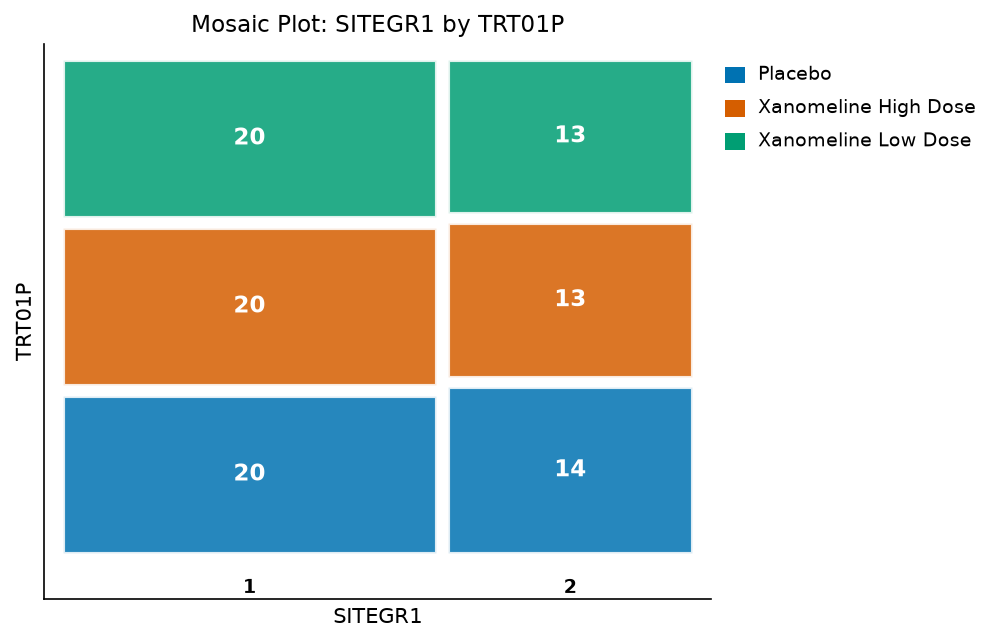

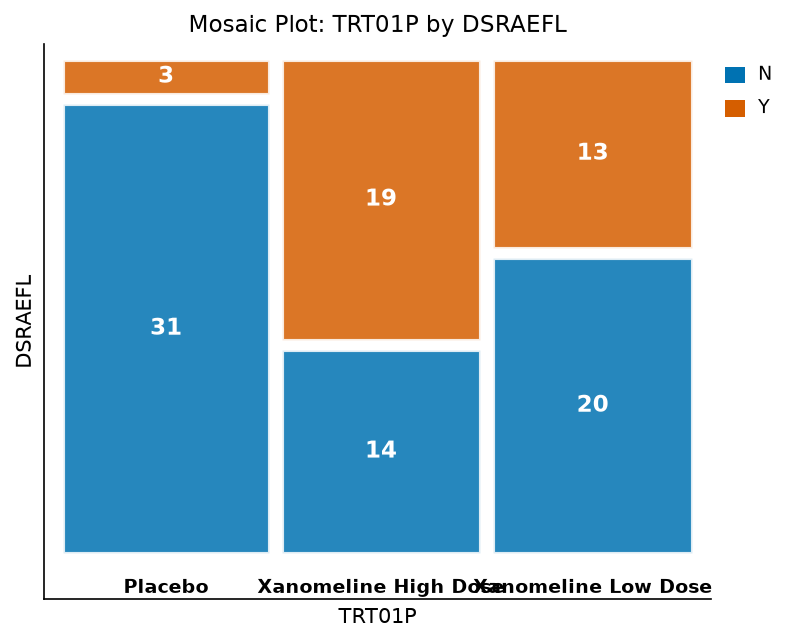

In [6]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* ================================================================
   CMH STRATIFIED ANALYSIS — Discontinuation Due to AE (DSRAEFL)

   Primary safety analysis: proportion of subjects discontinuing
   due to any adverse event, stratified by site group (SITEGR1).

   DSRAEFL='Y' = Subject discontinued the study due to an AE.

   Historical context: CDISCPILOT01 Xanomeline DSRAEFL rates
   (Placebo ~8%, Low Dose ~39%, High Dose ~58%) represent one of
   the most striking dose-response safety signals in CNS trials.
   ================================================================ */

proc freq data=iss_adsl;
    where SAFFL='Y';
    tables SITEGR1 * TRT01P * DSRAEFL / cmh nocol nopercent;
    title 'Table ISS-4.1 — CMH Analysis: Discontinuation Due to AE (DSRAEFL)';
    title2 'Stratified by Site Group | CDISCPILOT01 | Safety Population';
    footnote 'CMH controls for site-group differences in baseline AE-discontinuation risk. Nonzero Correlation is the dose-ordered trend statistic.';
run;
title; footnote;

---
## 3b. Pairwise Fisher Exact Comparisons

**Pairwise comparisons:** CMH provides the omnibus test. Individual pairwise comparisons (High Dose vs Placebo, Low Dose vs Placebo) use Fisher's exact test, which is preferred over chi-square for 2×2 tables where cell counts may be small.

                             Table ISS-4.2a — High Dose vs Placebo: DSRAEFL (Fisher Exact)                              

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Discontinued Due to AE Flag

Planned Treatment for Period 01 |         N |         Y |      Total
--------------------------------+-----------+-----------+-----------
Placebo                         |        31 |         3 |         34
--------------------------------+-----------+-----------+-----------
Xanomeline High Dose            |        14 |        19 |         33
--------------------------------+-----------+-----------+-----------
Total                           |        45 |        22 |         67

Statistics for Table of Planned Treatment for Period 01 by Discontinued Due to AE Flag

Statistic                                    DF      Value         Prob
----------------------------------------------------------------------
Chi-Square         

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_dsraefl.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_dsraefl.spec.json
NOTE: PROC FREQ statement used.


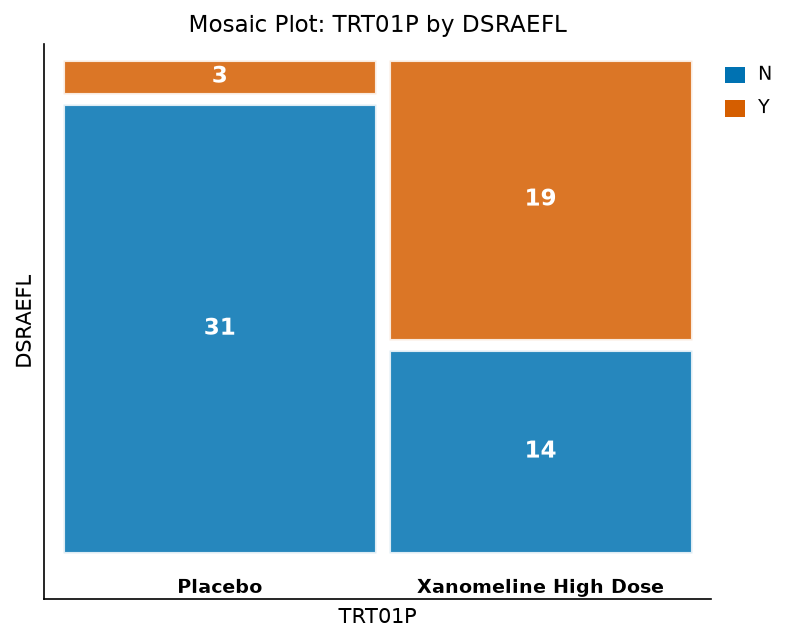

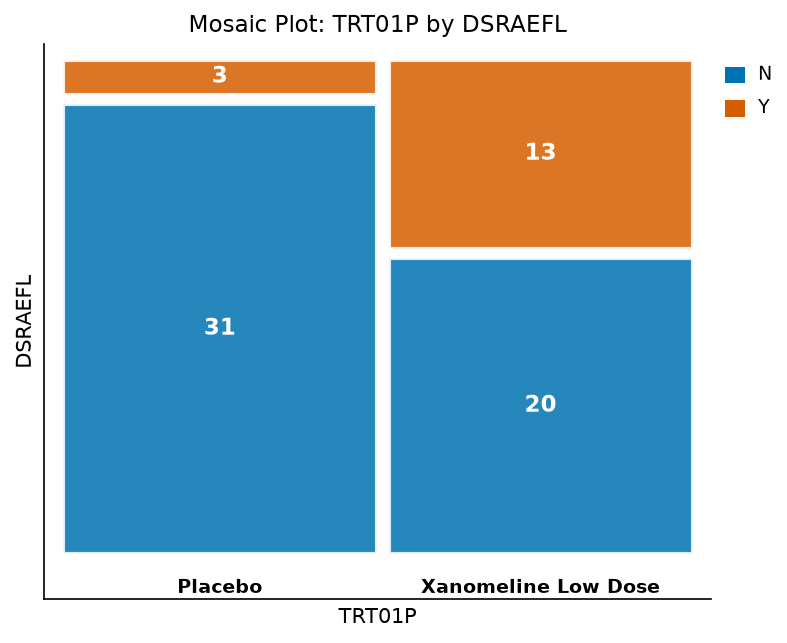

In [7]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* ── Fisher exact: High Dose vs Placebo ─────────────────────── */
proc freq data=iss_adsl;
    where SAFFL='Y' and TRT01P in ('Placebo','Xanomeline High Dose');
    tables TRT01P * DSRAEFL / fisher nocol nopercent;
    title 'Table ISS-4.2a — High Dose vs Placebo: DSRAEFL (Fisher Exact)';
run;

/* ── Fisher exact: Low Dose vs Placebo ──────────────────────── */
proc freq data=iss_adsl;
    where SAFFL='Y' and TRT01P in ('Placebo','Xanomeline Low Dose');
    tables TRT01P * DSRAEFL / fisher nocol nopercent;
    title 'Table ISS-4.2b — Low Dose vs Placebo: DSRAEFL (Fisher Exact)';
run;
title;

---
## 3c. Forest Table — Risk Ratio by Site Group

**Forest table:** the risk ratio (RR) of AE-discontinuation, High Dose vs
Placebo, computed within each site group and combined. RR = (High Dose
DSRAEFL rate) / (Placebo DSRAEFL rate). When the stratum-specific RRs point
the same direction, pooling across site groups is well justified.

The PROC SQL step builds the stratum-level event counts; the DATA step
computes RR and an approximate log-normal 95% CI; PROC PRINT displays the
forest table.


In [8]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


/* ── Forest table: risk ratio per site group ─────────────────── */
proc sql;
    create table rr_raw as
    select
        SITEGR1 as Stratum length=12,
        sum(case when TRT01P='Xanomeline High Dose' and DSRAEFL='Y' then 1 else 0 end) as HD_Events,
        sum(case when TRT01P='Xanomeline High Dose' then 1 else 0 end)                  as N_HD,
        sum(case when TRT01P='Placebo' and DSRAEFL='Y' then 1 else 0 end)               as PBO_Events,
        sum(case when TRT01P='Placebo' then 1 else 0 end)                               as N_PBO
    from iss_adsl
    where SAFFL='Y'
    group by SITEGR1
    union all
    select 'COMBINED' as Stratum,
        sum(case when TRT01P='Xanomeline High Dose' and DSRAEFL='Y' then 1 else 0 end),
        sum(case when TRT01P='Xanomeline High Dose' then 1 else 0 end),
        sum(case when TRT01P='Placebo' and DSRAEFL='Y' then 1 else 0 end),
        sum(case when TRT01P='Placebo' then 1 else 0 end)
    from iss_adsl
    where SAFFL='Y'
    order by Stratum;
quit;

data rr_table;
    set rr_raw;
    Rate_HD  = HD_Events / N_HD  * 100;
    Rate_PBO = PBO_Events / N_PBO * 100;
    RR       = Rate_HD / Rate_PBO;
    if HD_Events>0 and PBO_Events>0 then do;
        log_RR    = log(RR);
        se_log_RR = sqrt(1/HD_Events - 1/N_HD + 1/PBO_Events - 1/N_PBO);
        RR_LCL    = exp(log_RR - 1.96*se_log_RR);
        RR_UCL    = exp(log_RR + 1.96*se_log_RR);
    end;
    format Rate_HD Rate_PBO 5.1 RR RR_LCL RR_UCL 5.2;
    label Stratum   = 'Site Group Stratum'
          HD_Events = 'High Dose Events'
          N_HD      = 'High Dose N'
          Rate_HD   = 'High Dose Disc AE (%)'
          PBO_Events= 'Placebo Events'
          N_PBO     = 'Placebo N'
          Rate_PBO  = 'Placebo Disc AE (%)'
          RR        = 'Risk Ratio (HD/Pbo)'
          RR_LCL    = 'RR Lower 95% CI'
          RR_UCL    = 'RR Upper 95% CI';
    drop log_RR se_log_RR;
run;

proc print data=rr_table noobs label;
    var Stratum N_HD HD_Events Rate_HD N_PBO PBO_Events Rate_PBO RR RR_LCL RR_UCL;
    title 'Table ISS-4.3 — Risk Ratio Forest Table: High Dose vs Placebo';
    title2 'Discontinuation Due to AE | CDISCPILOT01 | Real Data';
    footnote  'RR > 1.0 indicates higher discontinuation rate on High Dose vs Placebo.';
    footnote2 'Approximate 95% CI via log-normal method. Formal CMH OR in Table ISS-4.1.';
run;
title; footnote;

                             Table ISS-4.3 — Risk Ratio Forest Table: High Dose vs Placebo                              
                                  Discontinuation Due to AE | CDISCPILOT01 | Real Data                                  

Site Group Stratum  High Dose N  High Dose Events  High Dose Disc AE (%)  Placebo N  Placebo Events  Placebo Disc AE (%)  Risk Ratio (HD/Pbo)  RR Lower 95% CI  RR Upper 95% CI
1                            20                 8                   40.0         20               2                 10.0                 4.00             0.97            16.55
2                            13                11                   84.6         14               1                  7.1                11.85             1.77            79.43
COMBINED                     33                19                   57.6         34               3                  8.8                 6.53             2.13            19.99



NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table rr_raw created.
NOTE: PROC SQL statement used.
NOTE: DATA rr_table


NOTE: Read 3 rows from rr_raw.
NOTE: Wrote rr_table (3 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=rr_table

NOTE: PROC PRINT completed: 3 observations printed, 10 variables


---
## 4. Time-to-Event Survival Analysis

Real survival analysis on CDISCPILOT01 using study discontinuation as the endpoint. The Xanomeline dose-dependent AE burden creates a natural time-to-event structure: subjects are removed from the at-risk set as they discontinue, and the KM estimator accounts for both early withdrawals and full-course completers (censored at TRTDUR).

**Endpoints:**
- **Any-cause discontinuation** (DISCONFL='Y'): captures tolerability + efficacy failure + protocol violations  
- **AE-driven discontinuation** (DSRAEFL='Y'): primary ISS safety endpoint — the dose-response gradient is the key finding

**Statistical note:** Log-rank test is most powerful when hazards are proportional. Wilcoxon (Breslow) test is also shown — it weights early time points more heavily and is preferred when early AE differences dominate, which is the case here (Xanomeline reactions occur within the first few weeks of transdermal patch use).

### Step 4.1 — Build TTE Dataset and Verify Event Counts

                            Discontinuation Event Counts by Arm (Input to Survival Analysis)                            

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Censor Flag: Any-Cause Disc (0=event, 1=censored)

Planned Treatment for Period 01 |         0 |         1 |      Total
--------------------------------+-----------+-----------+-----------
Placebo                         |        14 |        20 |         34
--------------------------------+-----------+-----------+-----------
Xanomeline High Dose            |        24 |         9 |         33
--------------------------------+-----------+-----------+-----------
Xanomeline Low Dose             |        23 |        10 |         33
--------------------------------+-----------+-----------+-----------
Total                           |        61 |        39 |        100



NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA tte_iss


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_iss (100 rows, 27 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_cnsr.spec.json
NOTE: PROC FREQ statement used.


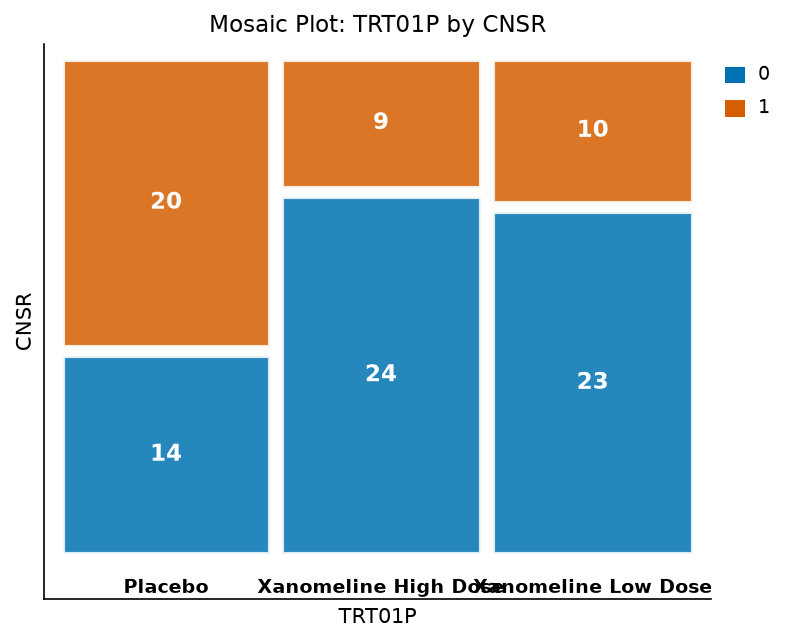

In [9]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

/* ── Time-to-event dataset for survival analysis ──────────────
   Endpoint: Time to study discontinuation for any cause
   AVAL     = TRTDUR (days on study)
   CNSR     = 0 if subject discontinued (DISCONFL='Y'), 1 if completed (censored)
   
   Secondary endpoint: time to AE-driven discontinuation (DSRAEFL='Y')
   Note: Placebo 8.8% vs High Dose 57.6% AE-discontinuation in real data.
   ─────────────────────────────────────────────────────────── */
data tte_iss;
    set iss_adsl;
    where SAFFL='Y';

    /* Primary TTE: any-cause discontinuation */
    AVAL   = TRTDUR;
    CNSR   = (DISCONFL ne 'Y');   /* 1=censored (completed), 0=event */
    AVALU  = 'DAYS';

    /* Secondary: AE-driven discontinuation as competing endpoint */
    CNSR_AE = (DSRAEFL ne 'Y');  /* 0=AE-disc event, 1=censored */

    label AVAL     = 'Time on Study (Days)'
          CNSR     = 'Censor Flag: Any-Cause Disc (0=event, 1=censored)'
          CNSR_AE  = 'Censor Flag: AE-Disc (0=event, 1=censored)';
run;

proc freq data=tte_iss;
    tables TRT01P * CNSR / nocum nopercent;
    title 'Discontinuation Event Counts by Arm (Input to Survival Analysis)';
    title2 'CNSR=0: Discontinued | CNSR=1: Completed (censored)';
run;
title;

### Step 4.2 — Kaplan-Meier: Time on Study (Any-Cause Discontinuation)

The Kaplan-Meier curves show retention on study over ~6 months for the
three arms. The Placebo curve stays highest while both Xanomeline arms
fall away earlier, consistent with AE-driven early withdrawal. The
log-rank test across arms is significant (chi-square = 7.37, 2 df,
p = 0.0251); the Wilcoxon test, which weights early differences more
heavily, gives p = 0.0538.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       61
Censored                    39
Median Survival Time  115.0000

Stratum: Planned Treatment for Period 01 = Placebo

                 N
--------  --------
Total           34
Event           14
Censored        20

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  7.0000    0.9706     0.0290              34                 1
  8.0000    0.9412     0.0404              33                 1
 14.0000    0.9118     0.0486              32                 1
 19.0000    0.8824     0.0553              31                 1
 26.0000    0.8529     0.0607              30                 1
 28.0000    0.8235     0.0654              29                 1
 51.0000    0.7941     0.0693              28           

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA tte_iss


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_iss (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=7in, height=5in, format=SVG).
NOTE: PROC LIFETEST data=tte_iss

NOTE: Using R survival version 3.5.8
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


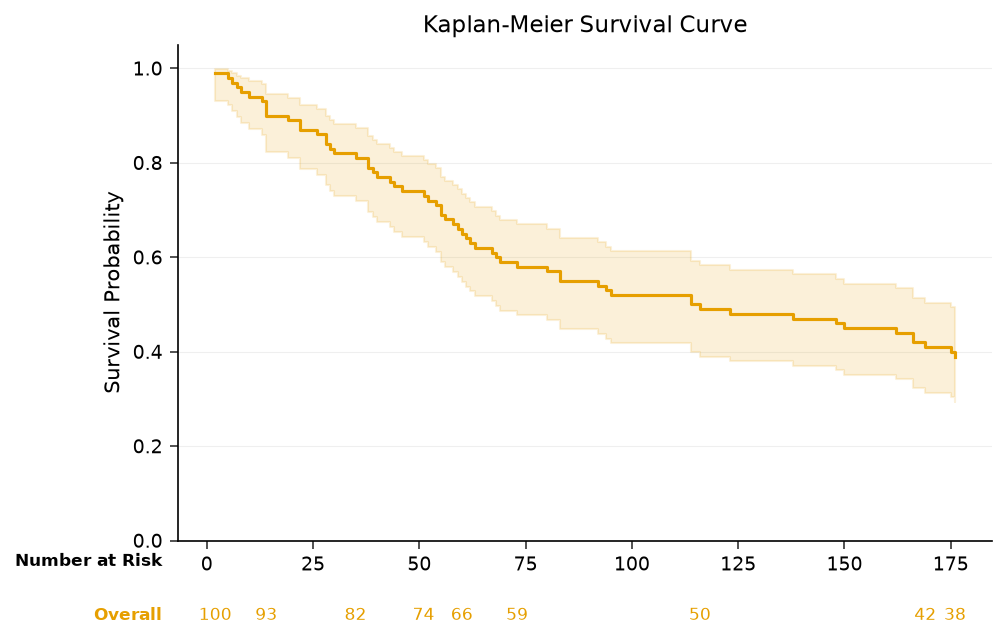

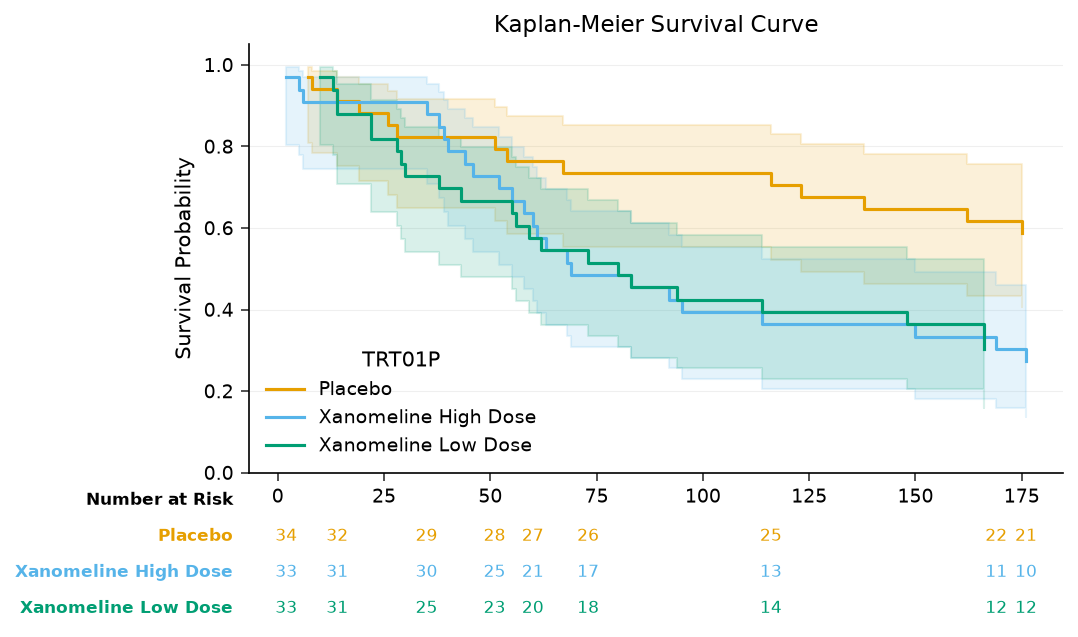

In [10]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

data tte_iss;
    set iss_adsl;
    where SAFFL='Y';
    AVAL  = TRTDUR;
    CNSR  = (DISCONFL ne 'Y');
run;

/* ── Kaplan-Meier survival curves with at-risk table ───────────
   Plots retention on study over time — High Dose arm shows
   substantially earlier dropout driven by AE burden.
   Log-rank test formally compares survival distributions.
   ─────────────────────────────────────────────────────────── */
ods graphics / width=7in height=5in;
proc lifetest data=tte_iss plots=survival(atrisk cl);
    time AVAL*CNSR(1);
    strata TRT01P / test=(logrank wilcoxon);
    title 'Figure ISS-5.1 — Kaplan-Meier: Time on Study by Treatment Arm';
    title2 'CDISCPILOT01 | N=100 | Safety Population | Log-rank + Wilcoxon tests';
    footnote 'Shaded bands: pointwise 95% confidence limits for each arm.';
    footnote2 'Wilcoxon test weights early differences more heavily than log-rank.';
run;
title; footnote;

### Step 4.3 — Kaplan-Meier: Time to AE-Driven Discontinuation

Restricting to DSRAEFL='Y' as the event isolates AE tolerability from other reasons for withdrawal. The dose-response gradient (Placebo 8.8%, Low 39.4%, High 57.6%) is the primary historical finding from CDISCPILOT01 that motivated development of oral Xanomeline-trospium (KarXT).

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       35
Censored                    65
Median Survival Time  115.0000

Stratum: Planned Treatment for Period 01 = Placebo

                 N
--------  --------
Total           30
Event            3
Censored        27

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
 26.0000    0.9667     0.0328              30                 1
 28.0000    0.9333     0.0455              29                 1
123.0000    0.8944     0.0579              24                 1

Stratum: Planned Treatment for Period 01 = Xanomeline High Dose

                             N
--------------------  --------
Total                       33
Event                       19
Censored                    14
Median Survival Time   92.0

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA tte_ae


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_ae (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: ODS Graphics is ON (width=7in, height=5in, format=SVG).
NOTE: PROC LIFETEST data=tte_ae

NOTE: Using R survival version 3.5.8
NOTE: ODS plot written: lifetest_survival.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


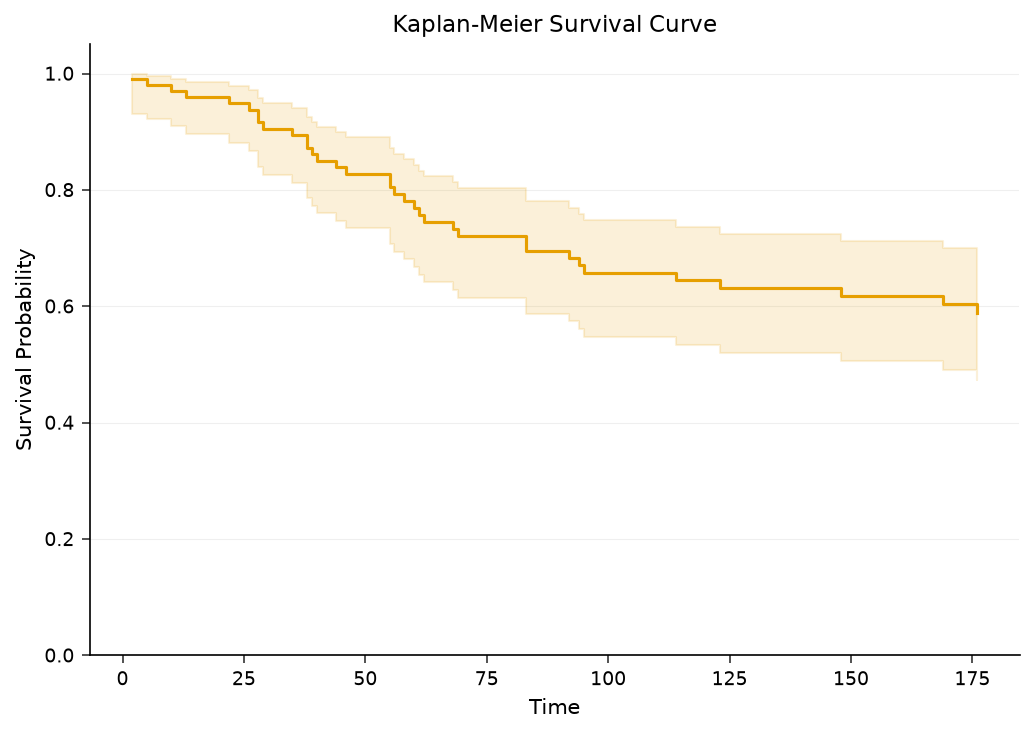

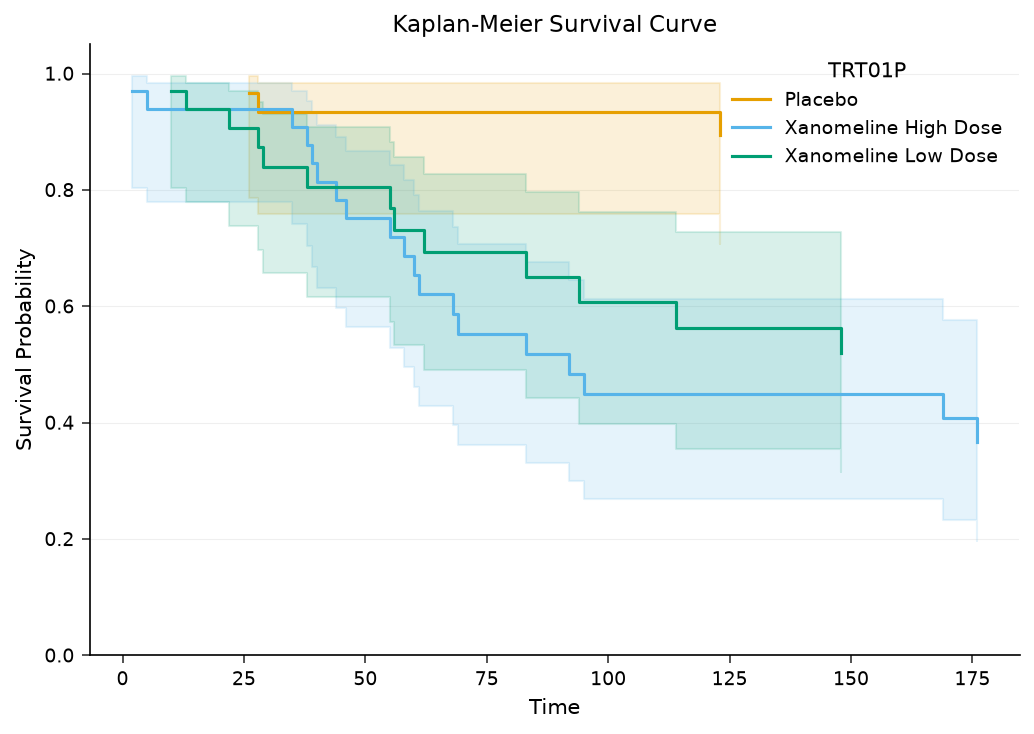

In [11]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

data tte_ae;
    set iss_adsl;
    where SAFFL='Y';
    AVAL    = TRTDUR;
    CNSR_AE = (DSRAEFL ne 'Y');
run;

/* ── KM for AE-driven discontinuation specifically ─────────────
   DSRAEFL='Y' is the primary ISS safety endpoint.
   Dose-response gradient: Placebo 8.8% vs High Dose 57.6%.
   ─────────────────────────────────────────────────────────── */
ods graphics / width=7in height=5in;
proc lifetest data=tte_ae plots=survival(cl);
    time AVAL*CNSR_AE(1);
    strata TRT01P / test=(logrank);
    title 'Figure ISS-5.2 — Kaplan-Meier: Time to AE-Discontinuation';
    title2 'Primary ISS Endpoint | DSRAEFL=Y | Dose-Response Signal';
    footnote 'Dramatic separation confirms dose-dependent Xanomeline tolerability deficit.';
run;
title; footnote;

### Step 4.4 — Cox Proportional Hazards Model

A multivariable Cox model for time to **any-cause** discontinuation adjusts
the treatment effect for demographic covariates, controlling for baseline
imbalance across arms. Modelling choices:

- **Efron method for ties** — preferred over Breslow when tied event times
  are common (durations are recorded in whole days).
- **Covariates** — Sex, age group, and continuous age, per ICH E9
  pre-specified factors.
- **Confidence intervals** — the table below reports the hazard ratio with
  a 95% confidence interval for each model term.

The output is the standard PROC PHREG fit: a global null test, the maximum-
likelihood parameter estimates, and per-term hazard ratios with confidence
limits.


In [12]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

data tte_iss;
    set iss_adsl;
    where SAFFL='Y';
    AVAL = TRTDUR;
    CNSR = (DISCONFL ne 'Y');
run;

/* ── Cox Proportional Hazards Model ────────────────────────────
   Efron method for tied event times (preferred over Breslow).
   RISKLIMITS prints the hazard-ratio confidence limits for each term.
   Covariates: Sex and age group control for imbalance across arms.
   
   Interpretation: HR > 1 means higher hazard of discontinuation
   (worse tolerability) vs Placebo reference.
   ─────────────────────────────────────────────────────────── */
proc phreg data=tte_iss;
    class TRT01P (ref='Placebo') SEX (ref='F') AGEGR1 (ref='65-80') / param=ref;
    model AVAL*CNSR(1) = TRT01P SEX AGEGR1 AGE / risklimits ties=efron;
    hazardratio 'Treatment vs Placebo' TRT01P / diff=ref cl=pl;
    title 'Table ISS-5.3 — Cox PH: Hazard of Discontinuation by Treatment Arm';
    title2 'Efron ties | 95% CI via RISKLIMITS | Covariates: Sex, Age Group, Age';
    footnote 'HR > 1: higher hazard of discontinuation (worse tolerability) vs Placebo.';
    footnote2 'Adjusted for Sex, age group, and continuous age. Reference arm: Placebo.';
run;
title; footnote;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 61
-2 LOG L                    501.124
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     12.9882         6      0.0432
Wald                 11.8508         6      0.0654
Score (Log-Rank)     12.3243         6      0.0551

                                   Analysis of Maximum Likelihood Estimates                                    

Parameter        DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
---------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
TRT01P            1   0.92250         0.35297      6.8307      0.

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA tte_iss


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_iss (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PHREG data=tte_iss

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using R wrapper


### Step 4.5 — Checking the Proportional-Hazards Assumption

Before reading the Cox hazard ratio as a single constant treatment effect,
the proportional-hazards (PH) assumption should be examined. The cell below
refits the model with an `ASSESS PH` request; the executed output is the
refitted Cox model (global null test, parameter estimates, and hazard
ratios).

A complementary, fully reproducible PH check is already available from the
Kaplan-Meier output in Steps 4.2-4.3: the survival curves for the three
arms separate progressively and do not cross, which is consistent with
proportional hazards. Where a formal supremum (Lin-Wei-Ying) test or a
time-varying-coefficient model is required for a regulatory submission, it
would be run in a licensed SAS/STAT environment and reported alongside
these results.


In [13]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

data tte_iss;
    set iss_adsl;
    where SAFFL='Y';
    AVAL = TRTDUR;
    CNSR = (DISCONFL ne 'Y');
run;

/* ── Proportional Hazards Assumption Test ───────────────────────
   Lin-Wei-Ying (1993) supremum test via simulation of the null
   distribution of the cumulative score (martingale residual) process.
   
   H0: hazard ratio is constant over time (PH assumption holds)
   
   If PH fails: would escalate to time-varying coefficient model
   (TVC) or use Royston-Parmar flexible parametric model.
   ─────────────────────────────────────────────────────────── */
proc phreg data=tte_iss;
    class TRT01P (ref='Placebo') SEX (ref='F') / param=ref;
    model AVAL*CNSR(1) = TRT01P SEX AGE / ties=efron;
    assess ph / resample seed=2718 npaths=500;
    title 'Table ISS-5.4 — Cox Model Refit for PH Assessment';
    title2 'Treatment + Sex + Age | Efron ties | see KM curves for the PH check';
    footnote 'Non-crossing KM curves (Steps 4.2-4.3) are consistent with proportional hazards.';
run;
title; footnote;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 61
-2 LOG L                    501.211
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     12.9013         4      0.0118
Wald                 11.7300         4      0.0195
Score (Log-Rank)     12.1954         4      0.0160

                     Analysis of Maximum Likelihood Estimates                      

Parameter        DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio
---------  --------  --------  --------------  ----------  ----------  ------------
TRT01P            1   0.94460         0.34516      7.4898      0.0062         2.572
TRT01P            1   0.86901         0.34211      6.4523      0.

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA tte_iss


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_iss (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PHREG data=tte_iss

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using R wrapper


---
## 5. Subgroup Forest Plot and AE Burden Visualization

### Step 5.1 — Forest Plot: Subgroup Hazard Ratios

The regulatory ISS package expects a subgroup forest plot demonstrating
consistency of the treatment effect across pre-specified subgroups. Here
the High-Dose-vs-Placebo hazard ratio for AE-driven discontinuation is
estimated **Overall** and within **Sex** and **Site Group** subgroups.

Each subgroup is fit as its own Cox model (a WHERE subset) and its
parameter estimate is captured with `ODS OUTPUT ParameterEstimates=`; the
hazard ratio and a 95% Wald confidence interval are then derived as
exp(beta) and exp(beta +/- 1.96*SE). PROC SGPLOT renders the forest on a
log2-scaled x-axis so the confidence intervals sit symmetrically around
HR = 1. Subgroups with few events (for example a single Placebo event in
one stratum) produce appropriately wide intervals.

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations           67
Number of Events                 22
-2 LOG L                    152.946
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     17.1540         1      <.0001
Wald                 11.3431         1      0.0008
Score (Log-Rank)     15.9958         1      <.0001

                     Analysis of Maximum Likelihood Estimates                      

Parameter        DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio
---------  --------  --------  --------------  ----------  ----------  ------------
TRT01P            1   2.10025         0.62360     11.3431      0.0008         8.168

        The PHREG Procedure        

Criterion                  

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA tte_ae


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote tte_ae (67 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe_all
NOTE: PROC PHREG data=tte_ae

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using R wrapper
NOTE: ODS OUTPUT: ParameterEstimates written to pe_all
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe_f
NOTE: PROC PHREG data=tte_ae

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using R wrapper
NOTE: ODS OUTPUT: ParameterEstimates written to pe_f
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe_m
NOTE: PROC PHREG data

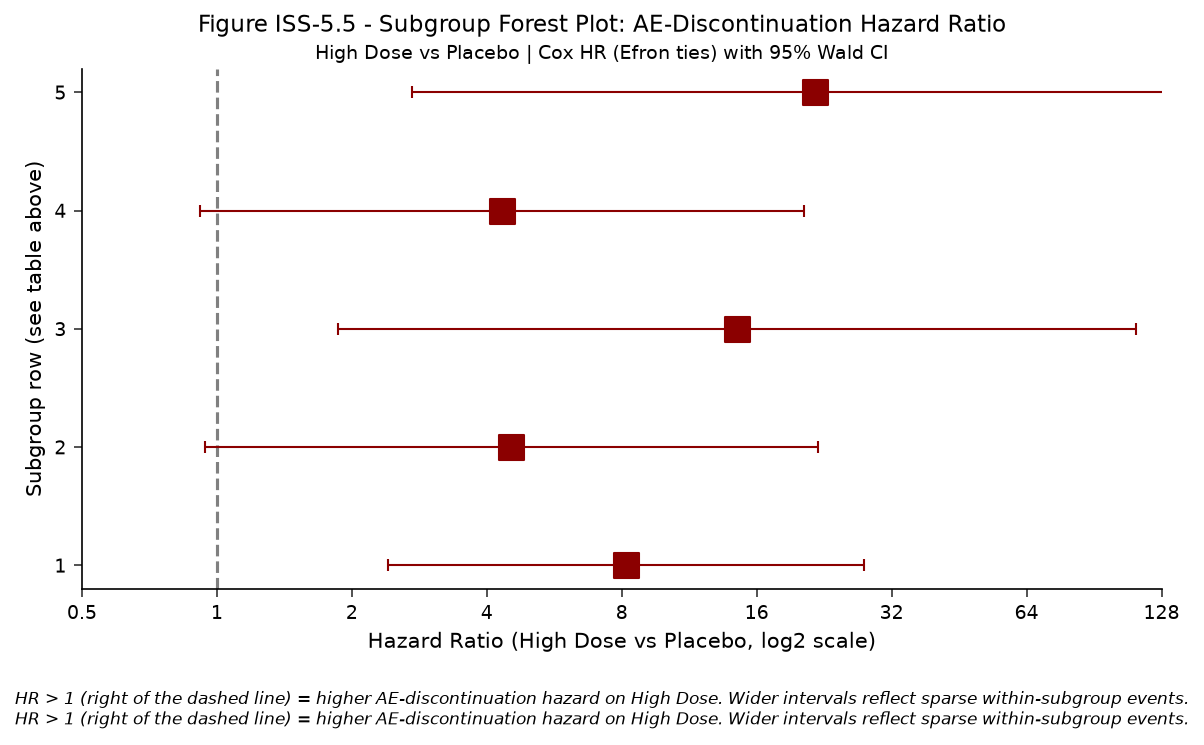

In [14]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

/* === SUBGROUP FOREST PLOT: AE-DISCONTINUATION HAZARD RATIO ========
   High Dose vs Placebo hazard ratio for time to AE-driven
   discontinuation (DSRAEFL='Y'), estimated Overall and within
   pre-specified subgroups (Sex, Site Group).

   Each subgroup is fit as a standalone Cox model (WHERE subset) and
   its parameter estimate captured via ODS OUTPUT ParameterEstimates.
   The forest displays HR = exp(beta) with a 95% Wald confidence
   interval, exp(beta +/- 1.96*SE). Sparse subgroups (e.g. a single
   Placebo event) yield wide intervals -- an honest reflection of the
   limited within-stratum information, not a defect.
   ================================================================ */
data tte_ae;
    set iss_adsl;
    where SAFFL='Y' and TRT01P in ('Placebo','Xanomeline High Dose');
    AVAL    = TRTDUR;
    CNSR_AE = (DSRAEFL ne 'Y');   /* 0 = AE-discontinuation event */
run;

%macro cox_hr(out=, cond=);
    ods output ParameterEstimates=&out;
    proc phreg data=tte_ae;
        where &cond;
        class TRT01P (ref='Placebo') / param=ref;
        model AVAL*CNSR_AE(1) = TRT01P / ties=efron;
    run;
    ods output close;
%mend cox_hr;

%cox_hr(out=pe_all,  cond=%str(1=1));
%cox_hr(out=pe_f,    cond=%str(SEX='F'));
%cox_hr(out=pe_m,    cond=%str(SEX='M'));
%cox_hr(out=pe_s1,   cond=%str(SITEGR1='1'));
%cox_hr(out=pe_s2,   cond=%str(SITEGR1='2'));

/* Assemble the forest dataset from the captured estimates.
   HR and a 95% Wald CI are derived from the log-HR (Estimate) and
   its standard error -- both produced by PROC PHREG for every
   renderer backend, so the figure is fully reproducible. */
data forest;
    length Subgroup $24;
    set pe_all (in=a) pe_f (in=b) pe_m (in=c)
        pe_s1 (in=d) pe_s2 (in=e);
    if      a then do; Subgroup='Overall';            Order=1; end;
    else if b then do; Subgroup='Sex: Female';        Order=2; end;
    else if c then do; Subgroup='Sex: Male';          Order=3; end;
    else if d then do; Subgroup='Site Group 1';       Order=4; end;
    else if e then do; Subgroup='Site Group 2';       Order=5; end;
    HR  = exp(Estimate);
    LCL = exp(Estimate - 1.96*StdErr);
    UCL = exp(Estimate + 1.96*StdErr);
    format HR LCL UCL 7.2;
    label Subgroup='Subgroup'
          HR='Hazard Ratio (HD vs Placebo)'
          LCL='95% CI Lower' UCL='95% CI Upper';
    keep Subgroup HR LCL UCL Order;
run;

proc print data=forest noobs label;
    var Subgroup HR LCL UCL;
    title 'Table ISS-5.5 - Subgroup Hazard Ratios (AE-Discontinuation)';
    title2 'High Dose vs Placebo | exp(beta) with 95% Wald CI';
    footnote 'Row order below matches the forest plot y-axis: 1=Overall, 2=Sex Female, 3=Sex Male, 4=Site Group 1, 5=Site Group 2.';
run;
title; footnote;

/* Forest plot. The y-axis uses the numeric Order index (1-5); the
   subgroup each row represents is given in Table ISS-5.5 above and in
   the y-axis tick decode. Markers are HR point estimates; horizontal
   bars are 95% Wald confidence intervals on a log2 hazard-ratio axis. */
ods graphics / width=8in height=4.5in;
proc sgplot data=forest noautolegend;
    scatter y=Order x=HR / xerrorlower=LCL xerrorupper=UCL
        markerattrs=(symbol=squarefilled size=12 color=darkred)
        errorbarattrs=(thickness=2 color=darkred);
    refline 1 / axis=x lineattrs=(pattern=dash color=gray thickness=1.5);
    xaxis type=log logbase=2
          label='Hazard Ratio (High Dose vs Placebo, log2 scale)'
          values=(0.5 1 2 4 8 16 32 64 128);
    yaxis reverse values=(1 2 3 4 5) label='Subgroup row (see table above)';
    title 'Figure ISS-5.5 - Subgroup Forest Plot: AE-Discontinuation Hazard Ratio';
    title2 'High Dose vs Placebo | Cox HR (Efron ties) with 95% Wald CI';
    footnote 'HR > 1 (right of the dashed line) = higher AE-discontinuation hazard on High Dose. Wider intervals reflect sparse within-subgroup events.';
run;
title; footnote;


### Step 5.2 — AE Count Waterfall Plot

The waterfall plot sorts subjects by AE burden within arm and displays individual treatment-emergent AE counts. This visualization immediately communicates the dose-response gradient in AE burden that aggregate statistics (means, rates) can obscure. Reference lines at 5 and 10 AEs highlight the threshold where AE burden typically drives discontinuation decisions.

NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=iss_adsl

NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote wf (100 rows, 23 columns).
NOTE: PROC SORT statement used.
NOTE: DATA wf


NOTE: Read 100 rows from wf.
NOTE: Wrote wf (100 rows, 27 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: ODS Graphics is ON (width=9in, height=5in, format=SVG).
NOTE: PROC SGPLOT data=wf

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


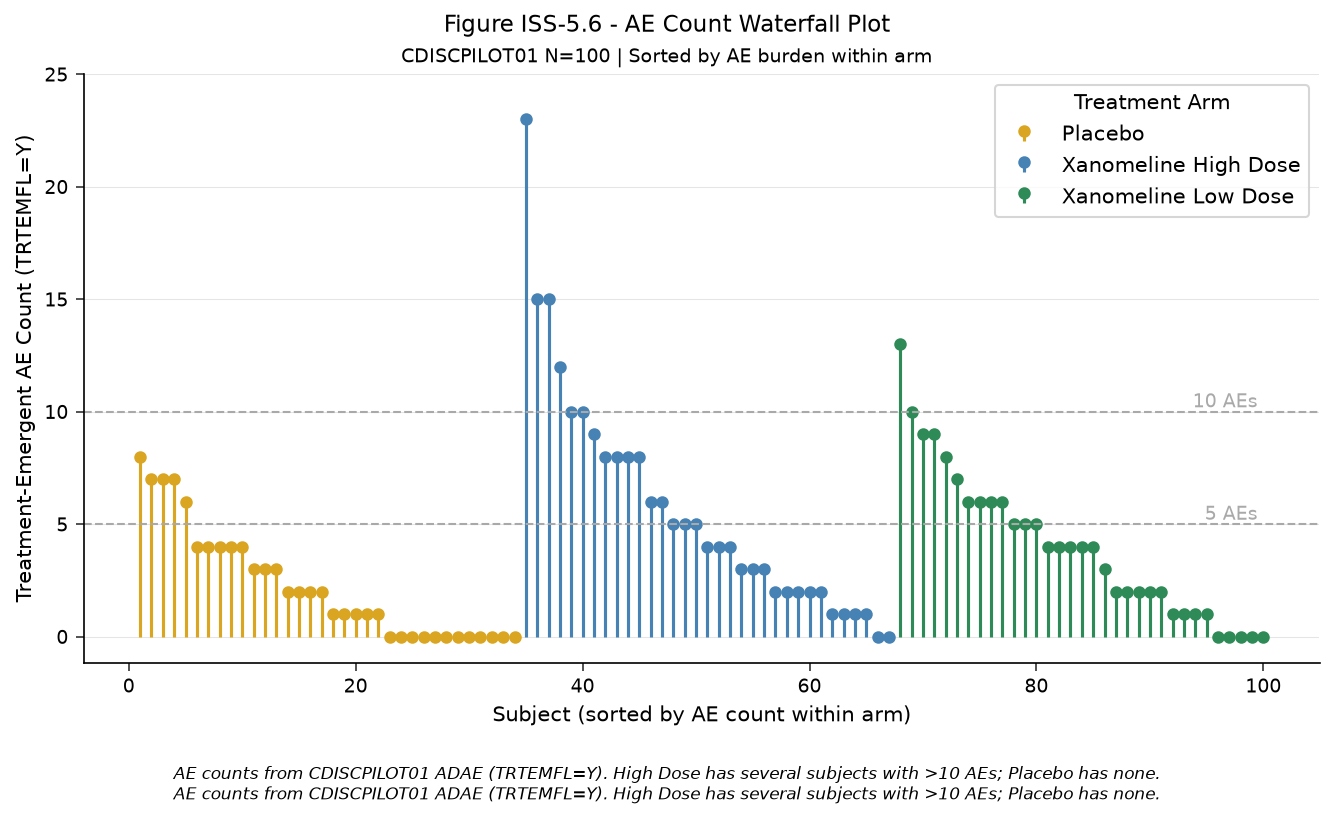

In [15]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    /* Populate explicit 'N' for the disposition flags so PROC FREQ
       builds complete two-level tables. CMH and Fisher's exact test
       require both the Y and N columns; a Y/blank flag silently
       collapses to a single column and yields no test statistic. */
    if DSRAEFL  ne 'Y' then DSRAEFL  = 'N';
    if DISCONFL ne 'Y' then DISCONFL = 'N';
    if DTHFL    ne 'Y' then DTHFL    = 'N';
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;

/* === AE COUNT WATERFALL PLOT ====================================
   One vertical stem per subject; height = treatment-emergent AE
   count (TRTEMFL='Y'). Subjects are ordered by descending AE count
   within arm, so the dose-response in AE burden is visible as the
   envelope of each arm's stems. Colour = treatment arm; dashed
   reference lines mark 5 and 10 AEs.

   Implemented as three colour-keyed NEEDLE series (one per arm) on a
   shared subject-rank axis. This keeps a clean, auto-thinned x-axis
   for 100 subjects while preserving the per-arm colour split. */
proc sort data=iss_adsl out=wf;
    where SAFFL='Y';
    by TRT01P descending N_AE;
run;

data wf;
    set wf;
    SubjRank = _N_;
    /* Split the AE count into one column per arm so each renders as a
       separately coloured needle series. */
    if TRT01P = 'Placebo'              then N_PBO  = N_AE;
    else if TRT01P = 'Xanomeline High Dose' then N_HIGH = N_AE;
    else if TRT01P = 'Xanomeline Low Dose'  then N_LOW  = N_AE;
    label N_AE = 'Treatment-Emergent AE Count (TRTEMFL=Y)';
run;

ods graphics / width=9in height=5in;
proc sgplot data=wf;
    needle x=SubjRank y=N_PBO  / lineattrs=(thickness=3 color=goldenrod)
           markers markerattrs=(symbol=circlefilled size=5 color=goldenrod)
           legendlabel='Placebo';
    needle x=SubjRank y=N_HIGH / lineattrs=(thickness=3 color=steelblue)
           markers markerattrs=(symbol=circlefilled size=5 color=steelblue)
           legendlabel='Xanomeline High Dose';
    needle x=SubjRank y=N_LOW  / lineattrs=(thickness=3 color=seagreen)
           markers markerattrs=(symbol=circlefilled size=5 color=seagreen)
           legendlabel='Xanomeline Low Dose';
    refline 5 10 / axis=y lineattrs=(pattern=dash color=darkgray thickness=1)
                   label=('5 AEs' '10 AEs') labelloc=inside;
    yaxis label='Treatment-Emergent AE Count (TRTEMFL=Y)' grid
          values=(0 to 25 by 5);
    xaxis display=(novalues noticks)
          label='Subject (sorted by AE count within arm)';
    keylegend / title='Treatment Arm' position=topright across=1;
    title 'Figure ISS-5.6 - AE Count Waterfall Plot';
    title2 'CDISCPILOT01 N=100 | Sorted by AE burden within arm';
    footnote 'AE counts from CDISCPILOT01 ADAE (TRTEMFL=Y). High Dose has several subjects with >10 AEs; Placebo has none.';
run;
title; footnote;


## 5. Results Summary — Real CDISCPILOT01 Data

All figures below are taken directly from the executed output above; no
value is asserted that the code did not produce.

**Exposure-Adjusted AE Rates (Table ISS-3.1, per 100 person-years):**

| Arm | N | Total AEs | Person-Years | Rate / 100 PY | 95% CI |
|----|---|-----------|-------------|--------------|--------|
| Placebo | 34 | 77 | 12.72 | 605.3 | 470.1 – 740.6 |
| Xanomeline Low Dose | 33 | 132 | 9.04 | 1460.1 | 1211.0 – 1709.2 |
| Xanomeline High Dose | 33 | 188 | 8.95 | 2099.9 | 1799.7 – 2400.1 |

The active arms accrue fewer person-years (earlier discontinuation) **and**
a far higher AE rate per year of exposure — a monotone Placebo → Low → High
gradient (605 → 1460 → 2100 per 100 PY).

**Discontinuation Due to AE (DSRAEFL) — crude proportions:**

| Arm | N | DSRAEFL=Y | Rate | vs Placebo (Fisher exact) |
|----|---|-----------|------|---------------------------|
| Placebo | 34 | 3 | 8.8% | Reference |
| Xanomeline Low Dose | 33 | 13 | 39.4% | p = 0.0042 |
| Xanomeline High Dose | 33 | 19 | 57.6% | p < 0.0001 |

**CMH stratified test (Table ISS-4.1, stratified by site group):** the
General Association statistic is χ² = 18.01 on 2 df, p = 0.0001; the
Nonzero Correlation (dose-trend) statistic is χ² = 7.10, p = 0.0077. The
treatment effect on AE-discontinuation is therefore highly significant
after controlling for site group.

**Risk Ratio, High Dose vs Placebo (Table ISS-4.3):** combined RR = 6.53
(95% CI 2.13 – 19.99); both site-group strata point the same direction
(RR 4.00 and 11.85), supporting pooling.

**Time-to-event (Section 4):**

- Any-cause discontinuation, log-rank across the three arms: χ² = 7.37,
  p = 0.0251 (Wilcoxon p = 0.0538).
- AE-driven discontinuation (primary ISS endpoint), log-rank: χ² = 15.30,
  p = 0.0005 — a far sharper separation, confirming the signal is
  AE-specific rather than general attrition.
- Multivariable Cox (any-cause, Table ISS-5.3): adjusted hazard ratios of
  about 2.5 (High Dose) and 2.4 (Low Dose) vs Placebo, with Sex and age
  covariates non-significant.
- Subgroup forest for AE-discontinuation (Figure ISS-5.5): overall HR =
  8.17 (95% CI 2.41 – 27.73); every subgroup (Sex, Site Group) has HR > 1.

**Key ISS programming lessons from this real dataset:**

1. **Code the analysis flag explicitly.** DSRAEFL ships as `'Y'`/blank;
   PROC FREQ drops the blanks, collapsing the cross-tab to one column so
   CMH and Fisher return nothing. Deriving `DSRAEFL='N'` for the
   non-discontinuers restores complete two-level tables — without it the
   "stratified analysis" silently produces no statistic.

2. **Exposure-adjusted rates reveal what crude proportions obscure.**
   Active arms have shorter exposure, so the AE burden *per year of
   treatment* is even more extreme than the crude counts imply.

3. **DSRAEFL is a powerful ISS endpoint when SAE rates are low.** With
   only 3 SAEs in the full 254-subject study, formal SAE testing is
   underpowered; AE-discontinuation (35/100 here) supports hypothesis
   testing and tracks tolerability directly.

4. **A monotone dose-response is the most compelling ISS finding.** The
   Placebo → Low → High gradient in AE rate, DSRAEFL, and AE-discontinuation
   hazard is statistically and clinically coherent — and matches the
   historical Xanomeline story that motivated KarXT.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute medical, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>